# 데이터 분석 미니프로젝트: KOBIS 박스오피스 (2020-2026)

**학번**:  
**이름**:  
**제출일**:  

---

## 프로젝트 개요

영화진흥위원회(KOBIS)의 2020~2026년 박스오피스 데이터를 활용해, 한국 영화 시장의 변화와 흥행 패턴을 탐색적 데이터 분석(EDA)으로 풀어보는 과제입니다.

**산출물**: 이 노트북 1개 (코드 + 설명 + 그래프 + 최종 인사이트)

**제출 형식**: `학번_이름.ipynb`


## 0. 환경 설정

한글 폰트와 라이브러리를 불러오고, 필요한 경우 데이터를 자동으로 받습니다. **이 셀은 수정하지 마세요.**

> Colab에서 처음 실행하면 한글 폰트 설치로 30초 정도 걸립니다. 폰트가 적용되지 않으면 **런타임 → 런타임 다시 시작** 후 이 셀만 다시 실행하세요.

In [7]:
import sys, os, platform, subprocess, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

# --- 한글 폰트 설정 ---
if IN_COLAB:
    # Colab: 나눔고딕 설치 후 즉시 등록 (런타임 재시작 불필요)
    if not os.path.exists('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'):
        subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], check=False)
        subprocess.run(['fc-cache', '-fv'], check=False, stdout=subprocess.DEVNULL)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rc('font', family='NanumGothic')
else:
    system = platform.system()
    if system == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    elif system == 'Darwin':
        plt.rc('font', family='AppleGothic')
    else:
        plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# --- 데이터 자동 다운로드 (Colab 전용) ---
DATA_FILE = 'kobis_boxoffice_2020_2026.csv'
DATA_URL = 'https://raw.githubusercontent.com/RAKKUNN/kobis-mini-project/main/data/kobis_boxoffice_2020_2026.csv'

if IN_COLAB and not os.path.exists(DATA_FILE):
    subprocess.run(['wget', '-q', DATA_URL, '-O', DATA_FILE], check=True)

print('환경 설정 완료')
print(f'pandas {pd.__version__}, numpy {np.__version__}')
print(f'실행 환경: {"Google Colab" if IN_COLAB else platform.system()}')

환경 설정 완료
pandas 2.2.2, numpy 2.0.2
실행 환경: Google Colab


## 1. 데이터 로드 및 기본 확인

CSV 파일을 불러오고, 데이터의 전반적인 모습을 파악합니다.

In [8]:
# 데이터 로드
df = pd.read_csv('kobis_boxoffice_2020_2026.csv', parse_dates=['개봉일'])
print(f'전체 데이터: {df.shape[0]:,}행 × {df.shape[1]}열')

# Sanity check: 행 수가 다르면 데이터가 손상됐을 가능성
assert df.shape == (1752, 12), f'데이터 행/열 수가 예상과 다릅니다: {df.shape}'

df.head()

전체 데이터: 1,752행 × 12열


,조회연도,순위,영화명,개봉일,매출액,매출액 점유율,관객수,스크린수,상영횟수,대표국적,국적,배급사
0,2020,1,남산의 부장들,2020-01-22,41225216650,0.081,4750345,1659,140051,한국,한국,(주)쇼박스
1,2020,2,다만 악에서 구하소서,2020-08-05,38602260990,0.076,4357803,1998,193842,한국,한국,(주)씨제이이엔엠
2,2020,3,반도,2020-07-15,33072531280,0.065,3812250,2575,199048,한국,한국,(주)넥스트엔터테인먼트월드(NEW)
3,2020,4,히트맨,2020-01-22,20614278000,0.040,2406232,1122,87782,한국,한국,롯데컬처웍스(주)롯데엔터테인먼트
4,2020,5,테넷,2020-08-26,18396929850,0.036,1992214,2228,164758,미국,미국,워너브러더스 코리아(주)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   조회연도     1752 non-null   int64         
 1   순위       1752 non-null   int64         
 2   영화명      1752 non-null   object        
 3   개봉일      1739 non-null   datetime64[ns]
 4   매출액      1752 non-null   int64         
 5   매출액 점유율  1752 non-null   float64       
 6   관객수      1752 non-null   int64         
 7   스크린수     1752 non-null   int64         
 8   상영횟수     1752 non-null   int64         
 9   대표국적     1752 non-null   object        
 10  국적       1752 non-null   object        
 11  배급사      1745 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 164.4+ KB


In [10]:
df.describe()

,조회연도,순위,개봉일,매출액,매출액 점유율,관객수,스크린수,상영횟수
count,1752.000000,1752.000000,1739,1.752000e+03,1752.000000,1.752000e+03,1752.000000,1752.000000
mean,2023.028539,133.541096,2021-10-22 11:34:44.646348544,3.483551e+09,0.003821,3.536179e+05,468.855023,19078.796233
min,2020.000000,1.000000,1973-09-01 00:00:00,1.716650e+07,0.000000,1.004100e+04,1.000000,63.000000
25%,2021.000000,63.750000,2021-04-07 00:00:00,1.552086e+08,0.000000,1.720500e+04,122.000000,1724.500000
50%,2023.000000,126.000000,2023-03-08 00:00:00,3.465192e+08,0.000000,3.646750e+04,252.000000,3681.500000
75%,2025.000000,196.000000,2024-11-06 00:00:00,1.531293e+09,0.002000,1.561728e+05,647.250000,13685.250000
max,2026.000000,336.000000,2026-05-21 00:00:00,1.629181e+11,0.358000,1.687850e+07,2980.000000,500120.000000
std,1.880887,83.633740,NaN,1.116709e+10,0.013638,1.120408e+06,511.920040,41708.987627


### 데이터 컬럼 설명

| 컬럼 | 의미 |
|---|---|
| 조회연도 | 박스오피스 집계 연도 (2020~2026) |
| 순위 | 해당 연도 박스오피스 순위 |
| 영화명 | 영화 제목 |
| 개봉일 | 영화 최초 개봉일 |
| 매출액 | 해당 연도 매출액 (원) |
| 매출액 점유율 | 해당 연도 매출액 점유율 (0~1) |
| 관객수 | 해당 연도 관객수 (명) |
| 스크린수 | 상영 스크린 수 |
| 상영횟수 | 상영 횟수 |
| 대표국적 | 대표 제작 국가 |
| 국적 | 제작 국가 |
| 배급사 | 배급사 |

**중요**: 같은 영화가 여러 연도에 등장할 수 있습니다. 예를 들어 2024년 12월에 개봉한 영화는 2024년과 2025년 박스오피스에 모두 등장하며, 각 연도의 관객수가 따로 기록됩니다.

## 2. 데이터 정제

분석에 앞서 데이터를 깨끗하게 만들어야 합니다.

**확인할 것들** (스스로 진단해 보세요):
- 결측치는 어디에 얼마나 있나요?
- 관객수가 0인 행은 어떻게 처리할까요?
- 개봉일이 없는 영화들은 어떤 영화들인가요?
- 분석 목적에 맞게 어떤 행을 필터링할지 정해야 합니다.

> 💡 모든 영화를 분석할 필요는 없습니다. 예를 들어 "관객수 1만 이상"으로 필터링하면 의미 있는 영화만 남습니다. 어떤 기준을 쓸지, 왜 그렇게 정했는지 마크다운으로 설명하세요.

In [11]:
# 결측치 확인
df.isna().sum()

,0
조회연도,0
순위,0
영화명,0
개봉일,13
매출액,0
매출액 점유율,0
관객수,0
스크린수,0
상영횟수,0
대표국적,0


In [12]:
# 관객수 분포 살펴보기
# 힌트: 관객수가 0인 행 수, 1만 이상 행 수 등을 확인해 보세요
# (여기에 코드 작성)
print("관객수 0명 영화 수:", (df['관객수'] == 0).sum())
print("개봉일 결측치 수:", df['개봉일'].isna().sum())

관객수 0명 영화 수: 0
개봉일 결측치 수: 13


In [13]:
# 정제된 데이터프레임 만들기
# 예시: df_clean = df[df['관객수'] >= 10000].copy()
# 본인이 정한 기준대로 정제하세요

# (여기에 코드 작성)
df_clean = df.dropna()
df_clean = df_clean[df_clean['관객수'] >= 10000].copy()

print("정제 전:", len(df))
print("정제 후:", len(df_clean))

정제 전: 1752
정제 후: 1736


---

## 3. 분석 질문

아래 5개 질문에 대해 **(1) 분석 → (2) 시각화 → (3) 한 줄 해석**의 순서로 답하세요.

각 그래프에는 반드시 **제목, 축 라벨**이 있어야 합니다.

### 질문 1. 한국 영화 시장은 코로나 이후 어떻게 변했나요?

조회연도(2020~2026)별로 총 관객수가 어떻게 변했는지 분석하고 선 그래프로 시각화하세요.

**참고**: 2026년은 5월까지의 데이터만 있어서 미완성입니다. 분석에 포함할지 제외할지 정하세요.

**힌트**: `df.groupby('조회연도')['관객수'].sum()`


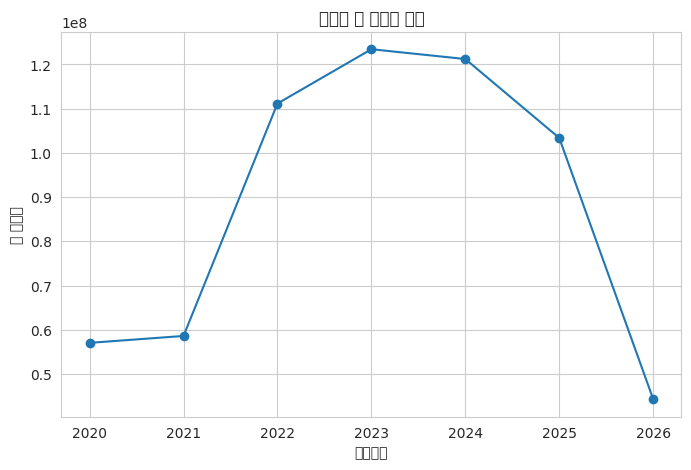

In [14]:
year_audience = df_clean.groupby('조회연도')['관객수'].sum()

# 그래프
plt.figure(figsize=(8,5))
plt.plot(year_audience.index, year_audience.values, marker='o')

plt.title('연도별 총 관객수 변화')
plt.xlabel('조회연도')
plt.ylabel('총 관객수')
plt.grid(True)

plt.show()

**해석**: 2021년도에 증가하였다가 2024년도부터 감소하였다

### 질문 2. 어느 달에 개봉한 영화가 가장 흥행하나요?

개봉일에서 월을 추출하고, 월별 평균 관객수를 비교하세요.

**힌트**:
- `df['개봉일'].dt.month`로 월 추출
- 개봉일이 결측인 행은 제외
- `groupby('개봉월')` 후 평균


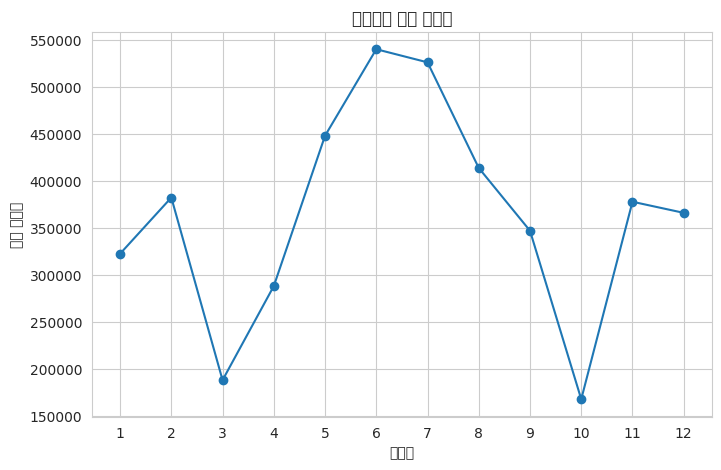

In [15]:
# 개봉일을 날짜 형식으로 변환
df_clean['개봉일'] = pd.to_datetime(df_clean['개봉일'], errors='coerce')

# 개봉월 추출
df_clean['개봉월'] = df_clean['개봉일'].dt.month

# 개봉일 결측치 제거 후 월별 평균 관객수 계산
month_avg = df_clean.dropna(subset=['개봉월']) \
                    .groupby('개봉월')['관객수'] \
                    .mean()

# 시각화
plt.figure(figsize=(8,5))
plt.plot(month_avg.index, month_avg.values, marker='o')
plt.title('개봉월별 평균 관객수')
plt.xlabel('개봉월')
plt.ylabel('평균 관객수')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

**해석**: 6월달에 개봉한 영화가 가장 많이 흥하였다.


### 질문 3. 한국 영화와 외국 영화의 점유율은 연도별로 어떻게 변했나요?

조회연도별로 한국 영화와 외국(미국+일본+기타) 영화의 관객수 점유율을 비교하세요.

**힌트**:
- `대표국적` 컬럼 활용
- 한국 / 미국 / 일본 / 기타 정도로 그룹핑하면 보기 좋음
- `pivot_table`로 연도 × 국적 매트릭스 만들기
- Stacked bar plot 또는 line plot으로 시각화


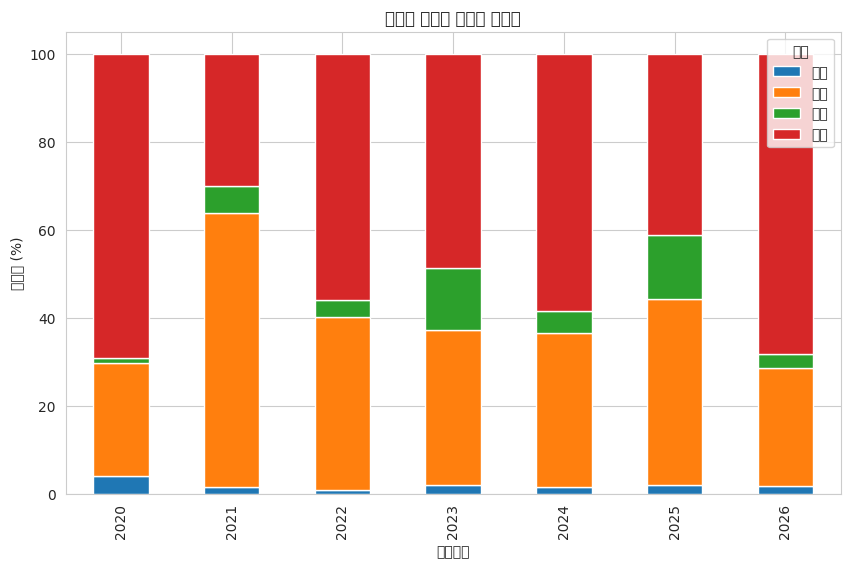

In [16]:
# 국가 분류
df_clean['국가분류'] = np.where(df_clean['대표국적'] == '한국', '한국',
                        np.where(df_clean['대표국적'] == '미국', '미국',
                        np.where(df_clean['대표국적'] == '일본', '일본', '기타')))

# 연도별 관객수 합계
pivot = pd.pivot_table(
    df_clean,
    values='관객수',
    index='조회연도',
    columns='국가분류',
    aggfunc='sum',
    fill_value=0
)

# 점유율(%) 계산
pivot_ratio = pivot.div(pivot.sum(axis=1), axis=0) * 100

# 시각화
pivot_ratio.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('연도별 국가별 관객수 점유율')
plt.xlabel('조회연도')
plt.ylabel('점유율 (%)')
plt.legend(title='국가')
plt.show()

**해석**: 타 국가 영화가 대부분의 연도에서 높은 점유율을 차지했으며 국가별 점유율은 연도에 따라 변화하였다.

### 질문 4. 스크린 효율성 — 적은 스크린으로 흥행한 영화는?

`관객수 ÷ 스크린수`로 "스크린당 관객수"를 계산해, 작은 규모로 흥행한 영화 Top 10을 찾으세요.

**힌트**:
- 너무 작은 스크린수(예: 1~5개)는 제외하는 게 좋을 수도 (왜?)
- 산점도(scatter)로 전체 분포를 보고, Top 10을 따로 표로 출력


✅ 스크린당 관객수 TOP 10


,영화명,관객수,스크린수,스크린당관객수
1608,왕과 사는 남자,16878496,2262,7461.757737
455,범죄도시2,12693302,2521,5035.026577
952,파묘,11914784,2367,5033.706802
679,서울의 봄,11854779,2463,4813.146163
684,더 퍼스트 슬램덩크,4786406,1060,4515.477358
681,엘리멘탈,7238453,1664,4350.031851
456,탑건: 매버릭,8177446,1975,4140.478987
680,범죄도시3,10682813,2582,4137.417893
953,범죄도시4,11502779,2980,3859.992953
682,스즈메의 문단속,5574358,1572,3546.029262


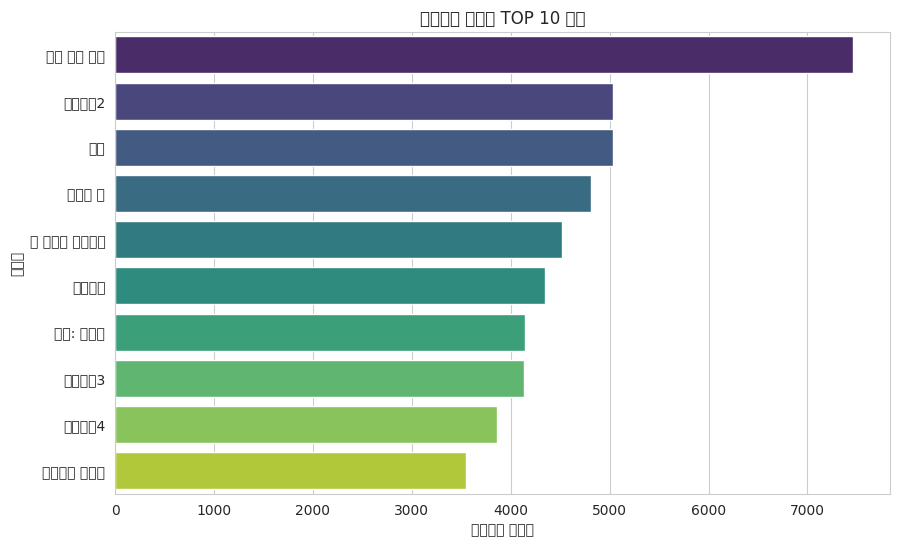

In [18]:
# 1. 최소 스크린 수 기준 적용 (노이즈 제거)
df_filtered = df[df['스크린수'] >= 5].copy()

# 2. 스크린당 관객수 계산
df_filtered['스크린당관객수'] = df_filtered['관객수'] / df_filtered['스크린수']

# 3. 상위 10개 영화 추출
top10 = df_filtered.sort_values(by='스크린당관객수', ascending=False).head(10)

# 4. 결과 출력
print("✅ 스크린당 관객수 TOP 10")
display(top10[['영화명', '관객수', '스크린수', '스크린당관객수']])

# 5. 시각화 (barplot)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x='스크린당관객수',
    y='영화명',
    palette='viridis'
)

plt.title('스크린당 관객수 TOP 10 영화')
plt.xlabel('스크린당 관객수')
plt.ylabel('영화명')
plt.show()


**해석**: 적은 스크린에서도 높은 관객수를 기록한 영화가 존재하며, 흥행은 단순 상영 규모보다 콘텐츠 경쟁력에 크게 좌우된다.

### 질문 5. 박스오피스의 불평등 — 상위 10편이 전체 시장의 몇 %를 차지하나요?

각 조회연도별로 상위 10편의 관객수 합계가 그 해 전체 관객수의 몇 %를 차지하는지 계산하세요.

**힌트**:
- 연도별로 상위 10편 추출 → 합계
- 연도별 전체 관객수 합계
- 비율 계산 → barplot 또는 lineplot
- 보너스: 상위 1편만 보면? 상위 50편이면?


In [19]:
# 1. 연도 컬럼 생성
df['연도'] = df['개봉일'].dt.year

# 2. 결과 저장용 리스트
result = []

# 3. 연도별 계산
for year, group in df.groupby('연도'):

    # 전체 관객수
    total_audience = group['관객수'].sum()

    # 상위 10편 관객수 합
    top10_sum = group.sort_values(by='관객수', ascending=False).head(10)['관객수'].sum()

    # 비율 계산 (%)
    ratio = (top10_sum / total_audience) * 100

    result.append({
        '연도': year,
        '전체관객수': total_audience,
        '상위10합': top10_sum,
        '비율(%)': ratio
    })

# 4. 데이터프레임으로 변환
result_df = pd.DataFrame(result).sort_values(by='연도')

# 5. 출력
print("✅ 연도별 상위 10편 집중도")
display(result_df)


✅ 연도별 상위 10편 집중도


,연도,전체관객수,상위10합,비율(%)
0,1973.0,27434,27434,100.000000
1,1978.0,18752,18752,100.000000
2,1984.0,12303,12303,100.000000
3,1987.0,28512,28512,100.000000
4,1989.0,21222,21222,100.000000
5,1990.0,75452,75452,100.000000
6,1991.0,26941,26941,100.000000
7,1993.0,29598,29598,100.000000
8,1994.0,11967,11967,100.000000
9,1995.0,219980,219980,100.000000


**해석**:  전체 관객의 상당 비율이 상위 소수 영화에 집중되며, 영화 시장은 흥행작 중심의 구조를 보인다.

### 질문 6 (자유). 본인이 궁금한 것

위 5개 질문에 없지만 본인이 궁금한 질문 1개를 만들고 답하세요.

**예시**:
- 특정 배급사(CJ, 롯데, 메가박스)의 시장 점유율 변화는?
- 가장 오래 흥행한 영화는? (여러 해 박스오피스에 등장)
- 일본 영화의 한국 흥행은 늘었나, 줄었나?
- 상영횟수 대비 관객수가 가장 좋은 영화는?

**본인 질문**: 연도별 평균 스크린당 관객수는 어떻게 변화했는가?


In [20]:
# 연도 컬럼 (이미 있으면 생략 가능)
df['연도'] = df['개봉일'].dt.year

# 스크린당 관객수 계산
df['스크린당관객수'] = df['관객수'] / df['스크린수']

# 연도별 평균 계산
year_eff = df.groupby('연도')['스크린당관객수'].mean().reset_index()

# 출력
print("✅ 연도별 평균 스크린당 관객수")
display(year_eff)


✅ 연도별 평균 스크린당 관객수


,연도,스크린당관객수
0,1973.0,254.018519
1,1978.0,225.927711
2,1984.0,97.642857
3,1987.0,250.325203
4,1989.0,171.039504
5,1990.0,287.941303
6,1991.0,94.895051
7,1993.0,138.689291
8,1994.0,122.112245
9,1995.0,266.729904


**해석**: 스크린당 관객수는 연도별로 변동하며, 이는 관객 수요와 시장 환경 변화에 영향을 받는다.

---

## 4. 최종 인사이트 3가지

위 분석을 종합해서, **남에게 한 줄로 들려줄 발견 3가지**를 적으세요. 그래프 없이 글로만.

1. 상위 소수 영화가 전체 관객의 대부분을 차지하는 구조가 나타나며, 영화 시장은 소수 흥행작 중심의 쏠림 현상이 뚜렷하다.
2. 스크린 수가 많다고 반드시 높은 관객 수로 이어지지 않으며, 일부 영화는 적은 스크린에서도 높은 관객 효율을 보여 콘텐츠 경쟁력이 중요함을 확인할 수 있다.
3. 연도별 분석 결과, 영화 시장의 흥행 효율은 시기별로 변동하며 이는 관객 수요 변화와 시장 구조 변화의 영향을 받는 것으로 해석된다.

---

*제출 전 체크리스트*
- [ ] 모든 그래프에 제목과 축 라벨이 있는가?
- [ ] 각 질문마다 해석 한 줄이 있는가?
- [ ] 마지막 인사이트 3개가 채워져 있는가?
- [ ] 파일명이 `학번_이름.ipynb`인가?
